<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/HOUSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler




house = pd.read_csv("house.csv")
house.shape
house.ndim
house.head()
house.tail()
house.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
missing = house.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False) #harek column ma kati ota missing value xa nikalxa ani sort garxa thulo dekhi sano

In [ ]:
house['LotFrontage'] = house['LotFrontage'].fillna(house['LotFrontage'].median()) #median nikalxa lotfrontage bhne data ko ani tyo median value NAN sanga replace hanxa sab data ma

In [ ]:
house['MasVnrType']=house['MasVnrType'].fillna(house['MasVnrType'].mode()[0]) #sab bhnda besi repeated bhako kura lai nan ko sato replace garxa ani esko case ma dhunga herxa kun ley baneko ghar xa tyo replace hanxa

<Axes: xlabel='SalePrice'>

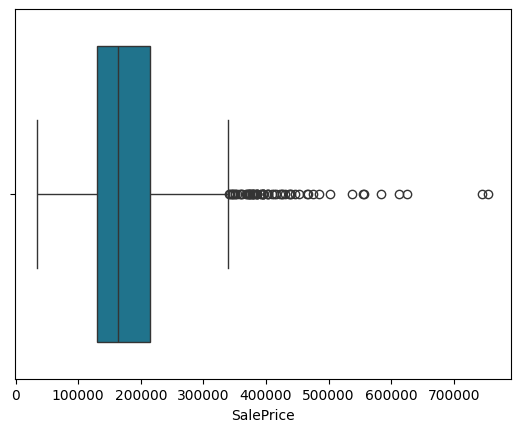

In [8]:
sns.boxplot(x=house['SalePrice'],color='#0E7C9E')

In [10]:
Q1=house['SalePrice'].quantile(0.25)
Q3=house['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower,upper =Q1 - 1.5*IQR, Q3 + 1.5*IQR
iqr_outliers = house[(house['SalePrice']<lower) | (house['SalePrice']>upper)]

In [12]:
house['SalePrice_zscore']=stats.zscore(house['SalePrice'])
zscore_outliers = house[house['SalePrice_zscore'].abs() > 3]

print(f"IQR : {len(iqr_outliers)} Z-score:{len(zscore_outliers)}")

IQR : 61 Z-score:22


Text(0.5, 1.0, 'Distribution of SalePrice')

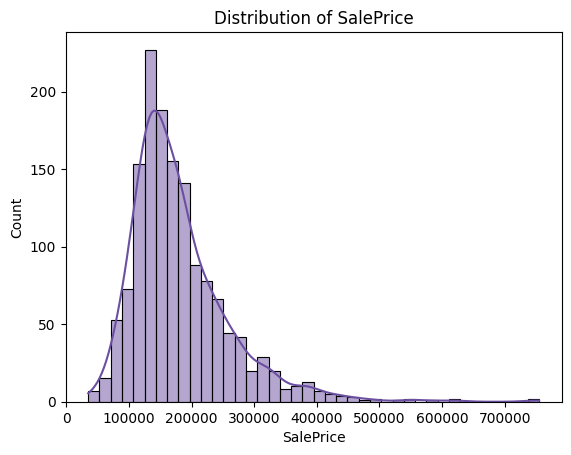

In [13]:
sns.histplot(house['SalePrice'], bins=40, kde=True, color='#6B4FA0')
plt.title("Distribution of SalePrice")


Text(0.5, 1.0, 'Count of Houses by Style')

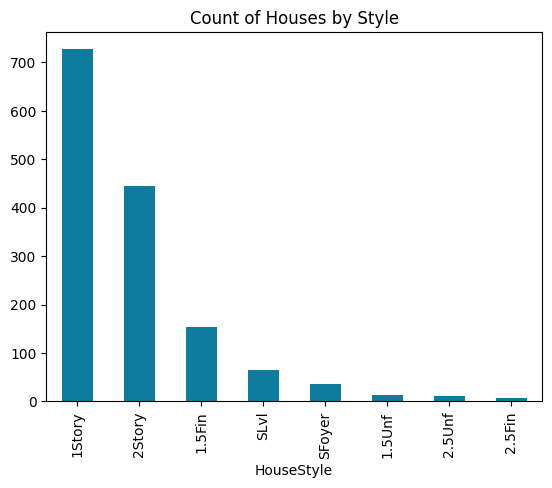

In [14]:
house['HouseStyle'].value_counts().plot(kind='bar', color='#0E7C9E')
plt.title("Count of Houses by Style")


Text(0, 0.5, 'SalePrice ($)')

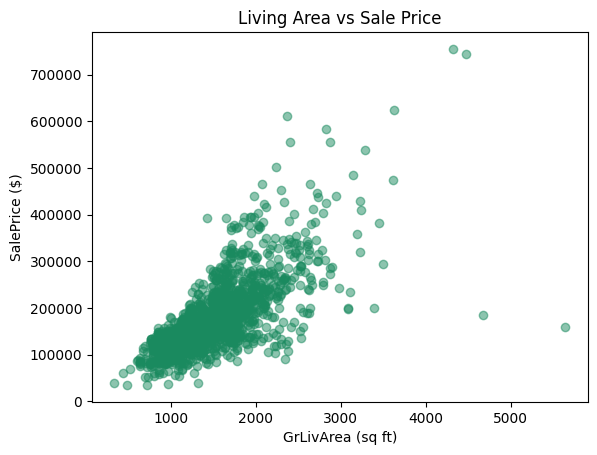

In [15]:
plt.scatter(house['GrLivArea'], house['SalePrice'],
            alpha=0.5, color='#1A8A5F')
plt.title("Living Area vs Sale Price")
plt.xlabel("GrLivArea (sq ft)"); plt.ylabel("SalePrice ($)")


In [16]:
numeric = house.select_dtypes(include='number')
corr = numeric.corr()


In [17]:
top = corr['SalePrice'].sort_values(ascending=False).head(10)
print(top)

SalePrice           1.000000
SalePrice_zscore    1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
Name: SalePrice, dtype: float64


<Axes: >

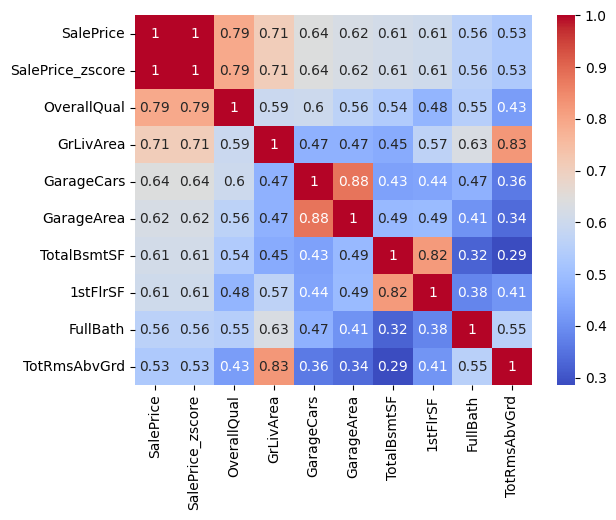

In [18]:
sns.heatmap(house[top.index].corr(), annot=True, cmap='coolwarm')


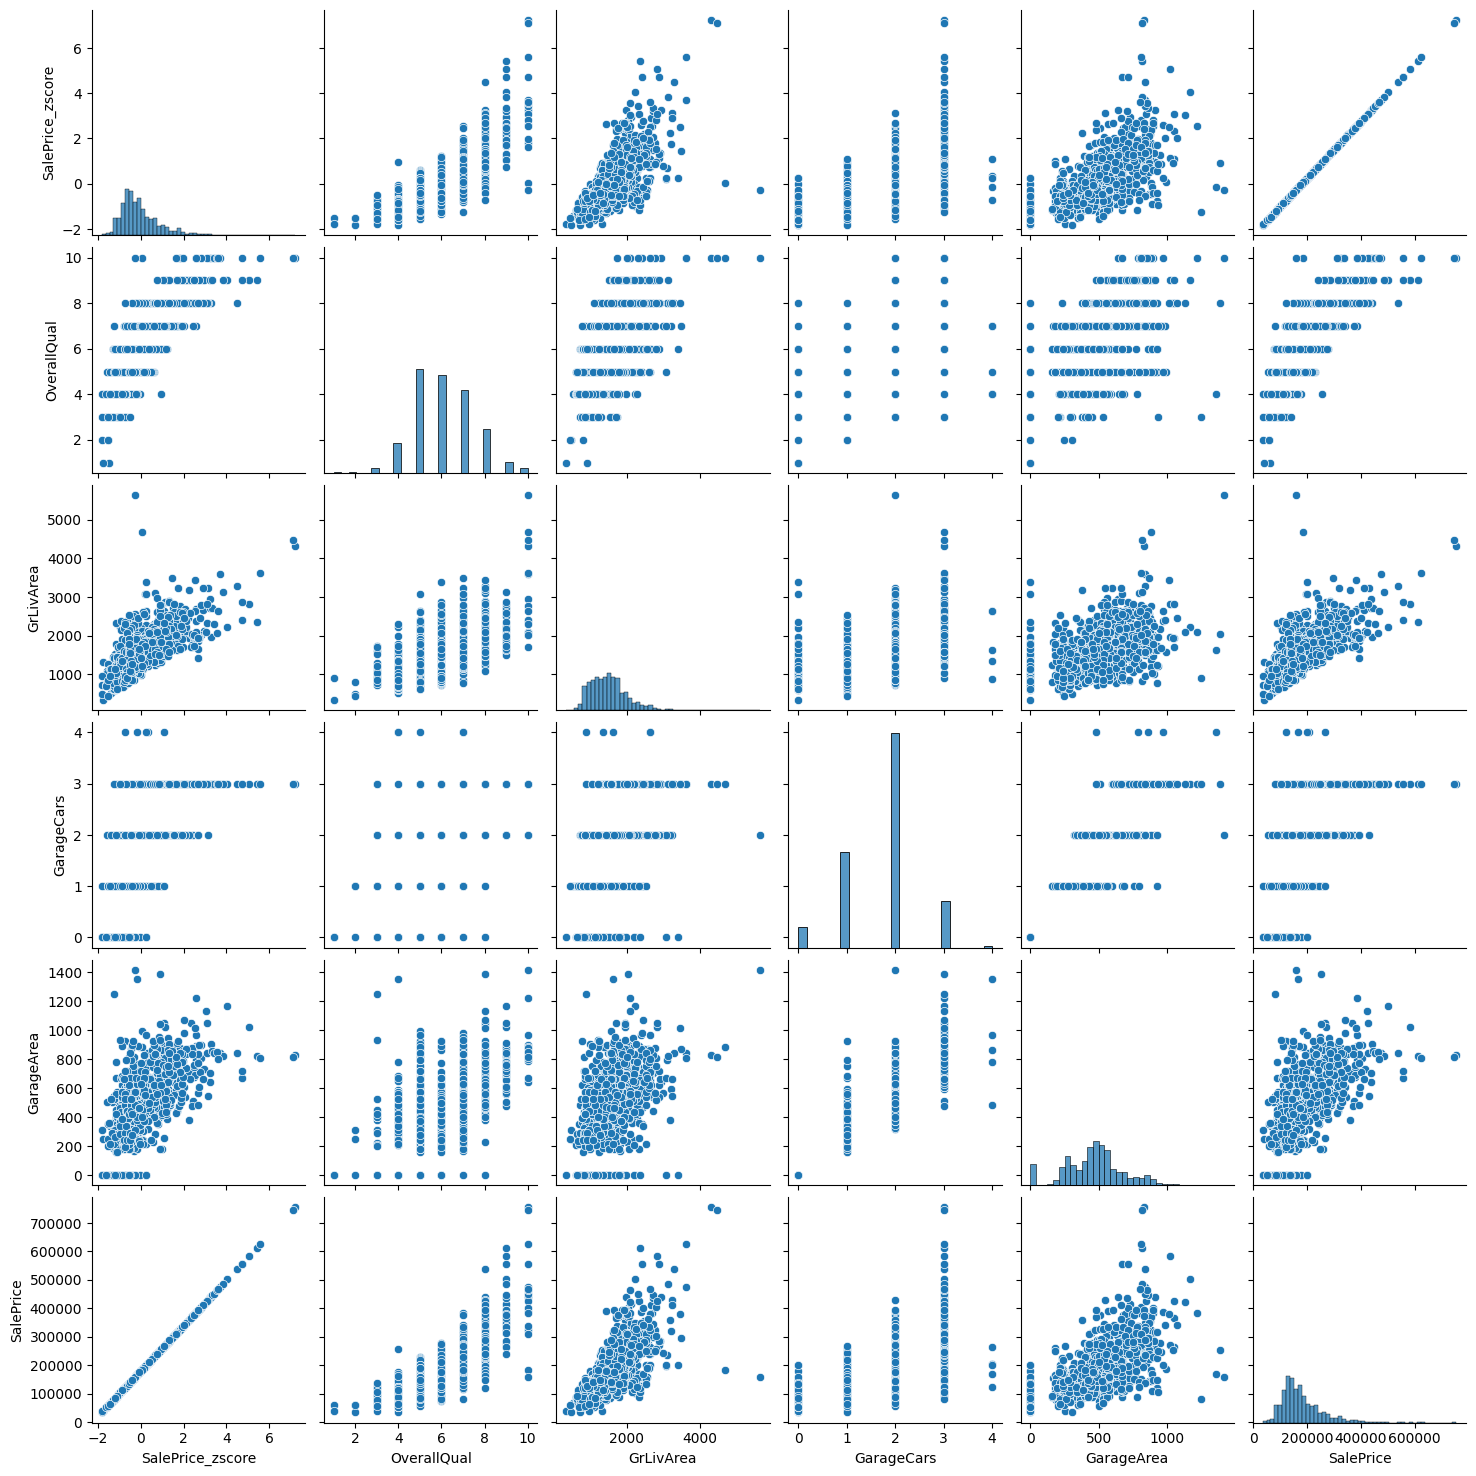

In [19]:
top5 = top.index[1:6]
sns.pairplot(house[list(top5) + ['SalePrice']])


In [22]:
le = LabelEncoder()
house['ExterQual_encoded'] = le.fit_transform(house['ExterQual'])


In [23]:
neighborhood_dummies = pd.get_dummies(house['Neighborhood'], //
                                       prefix='Nbhd')
house = pd.concat([house, neighborhood_dummies], axis=1)

In [25]:
scaler = StandardScaler() \\
house['GrLivArea_scaled'] = scaler.fit_transform(
    house[['GrLivArea']])




In [26]:
minmax = MinMaxScaler() \\
house['GrLivArea_minmax'] = minmax.fit_transform(
    house[['GrLivArea']])


In [27]:
house.to_csv("HOUSE_clean.csv",index = False)
print("Saved")

from google.colab import files
files.download("HOUSE_clean.csv")

Saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>